# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective


Sampling follows annealed MCMC

Input:
- Transition kernels $k_t(· | ·)$
- Initial distribution $p_T(·)$
- Number of steps $N$

Sampling steps:
- Initialize $x_T \sim p_T(·)$
- for $t = T, T-1, ... ,  0$ do
	- for $i = 1, ... ,  N$ do
		- $x_t \sim k_t(· | x_t)$
	- end for
	- $x_{t-1} = x_t$
- end for

For our transition kernel, we choose ULA algorithm
$$q(x_t\mid x_{t-1}) = N(x_{t-1} + \frac{\sigma_L^2}{2} \nabla_x f(x_{t-1}), \sigma_L^2 I)$$
We choose step size $\beta_t$
$$x_{t+1} = x_t - \beta_t \nabla_x p_t(x) + \sqrt{2} \beta_t z$$
where
$$\nabla \text{model output} = \nabla_x p_t(x) = \frac{\epsilon_{\theta}(x_t, t)}{\sqrt{1-\bar{\alpha}_t}}$$
See appendix b.2 of reduce reuse recycle and section 2.2

### Setup

In [20]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from scipy.stats import norm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- hyperparams ----

# Training hyperparams
n_steps = 15_000
batch_size = 128
lr = 3e-4
n_diffusion_steps = 100
ckpt_dir = "model_checkpoints"

# Sampling hyperparms
n_samples = 50_000
n_langevin_steps = 5

### Schedule

In [21]:
def cosine_beta_schedule(timesteps, s=0.008):
	"""Cosine noise schedule, taken from reduce reuse recycle code"""
	steps = timesteps + 1
	t = torch.linspace(0, timesteps, steps, dtype=torch.float32) / timesteps
	alphas_cumprod = torch.cos((t + s) / (1 + s) * math.pi * 0.5) ** 2
	alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
	betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
	return torch.clip(betas, 0, 0.999)

betas = cosine_beta_schedule(n_diffusion_steps).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)  # alphā_t

ts_desc = torch.arange(n_diffusion_steps - 1, -1, -1, device=device)

### Model

In [22]:
class SinusoidalTimeEmbedding(nn.Module):
	def __init__(self, dim):
		super().__init__()
		self.dim = dim

	def forward(self, t):
		if t.dim() == 2:
			t = t.squeeze(-1)

		half = self.dim // 2
		freqs = torch.exp(
			-math.log(10000) * torch.arange(half, device=t.device) / half
		)
		args = t[:, None] * freqs[None, :]
		emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

		if self.dim % 2 == 1:
			emb = F.pad(emb, (0, 1))

		return emb


class MLP(nn.Module):
	def __init__(
		self,
		x_dim=1,
		hidden_dim=128,
		time_dim=32,
		n_layers=4,
	):
		super().__init__()

		self.time_embed = SinusoidalTimeEmbedding(time_dim)

		self.input = nn.Linear(x_dim + time_dim, hidden_dim)

		self.layers = nn.ModuleList(
			[nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
		)

		self.output = nn.Linear(hidden_dim, x_dim)

	def forward(self, x, t):
		t_emb = self.time_embed(t)
		h = torch.cat([x, t_emb], dim=-1)

		h = self.input(h)
		h = F.silu(h)

		for layer in self.layers:
			h = h + F.silu(layer(h))

		return self.output(h)

### Dataset

In [23]:
@torch.no_grad()
def generate_gaussian_mixture(n_samples, means, stds, device='cpu'):
    """Generates mixture of gaussians according to inputted means and standard deviations"""
    means = torch.as_tensor(means, dtype=torch.float32)
    n_gaussians = len(means)
    
    if isinstance(stds, (int, float)):
        stds = torch.full((n_gaussians,), float(stds))
    else:
        stds = torch.as_tensor(stds, dtype=torch.float32)
        assert len(stds) == n_gaussians, f"stds length {len(stds)} != n_gaussians {n_gaussians}"
        
    component_ids = np.random.choice(n_gaussians, size=n_samples)
    samples = torch.zeros(n_samples, 1, device=device)
    
    for i in range(n_gaussians):
        mask = component_ids == i
        samples[mask] = torch.normal(
			mean=float(means[i]),
			std=float(stds[i]),
			size=(mask.sum(), 1)
		).to(device)
    
    return samples


@torch.no_grad()
def compute_sigma_0(dataset_config):
    """Computes overall standard deviation for dataset according to dataset config parameters"""
    means = np.array(dataset_config['means'])
    stds = dataset_config['stds']
    
    if isinstance(stds, (int, float)):
        stds = np.full_like(means, stds, dtype=float)
    else:
        stds = np.array(stds)
    
    mean_of_mixture = np.mean(means)
    expected_x_squared = np.mean(stds**2 + means**2)
    variance = expected_x_squared - mean_of_mixture**2
    sigma_0 = np.sqrt(variance)
    
    return sigma_0


@torch.no_grad()
def compute_mixture_pdf(dataset_config, x_axis, temperature=1.0):
    """Computes analtytical pdf of training dataset from dataset config file, used for plotting"""
    means = np.array(dataset_config['means'])
    stds = dataset_config['stds']
    
    if isinstance(stds, (int, float)):
        stds = np.full(len(means), stds)
    else:
        stds = np.array(stds)
    
    temperature_scale = 1.0 / np.sqrt(temperature)
    stds = stds * temperature_scale
    
    n_gaussians = len(means)
    pdf = np.zeros_like(x_axis)
    
    for mu, sigma in zip(means, stds):
        pdf += norm.pdf(x_axis, loc=mu, scale=sigma)
    
    pdf /= n_gaussians  
    
    return pdf

### Train Model

In [24]:
def train_model(config, temperature=1.0, log_every=5000):
	"""Trains model according to a dataset defined by dataset_config"""
	name, dataset_config = config

	x0_all = generate_gaussian_mixture(
        n_samples=dataset_config["n_samples"],
		means=dataset_config["means"],
		stds=dataset_config["stds"],
        device='cpu',
    )

	loader = DataLoader(
		TensorDataset(x0_all),
		batch_size=batch_size,
		shuffle=True,
		drop_last=True,
		num_workers=0,      # keep simple; set >0 if you want
		pin_memory=True,    # helps H2D transfer
	)

	model = MLP().to(device)
	opt = optim.Adam(model.parameters(), lr=lr)
	model.train()

	data_iter = iter(loader)

	for step in range(1, n_steps + 1):
		try:
			(x0,) = next(data_iter)
		except StopIteration:
			data_iter = iter(loader)  # reshuffles because shuffle=True
			(x0,) = next(data_iter)

		x0 = x0.to(device, non_blocking=True)

		t = torch.randint(0, n_diffusion_steps, (batch_size, 1), device=device)
		a_bar = alpha_bars[t]
		
		noise = torch.randn_like(x0)
		xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise

		eps_hat = model(xt, t)
		loss = ((noise - eps_hat) ** 2).mean()

		opt.zero_grad()
		loss.backward()
		opt.step()

		if step % log_every == 0:
			print(f"temperature={temperature} step={step} loss={loss.item():.4f}")

	save_path = f"{ckpt_dir}/{name}_{temperature:.1f}.pt"
	torch.save(model.state_dict(), save_path)
	print(f"Trained model saved to {save_path}")

	return model

### Sampling

In [25]:
@torch.no_grad()
def compute_tsr(t_batch, temperature, dataset_config):
	"""Computes temporal score rescaling coefficient"""
	sigma_0 = compute_sigma_0(dataset_config)
	sigma = sigma_0

	a_bar = alpha_bars[t_batch[0,0].long().item()]
	sigma_t = torch.sqrt(1.0 - a_bar)
	alpha_t = torch.sqrt(a_bar)

	eta_t = (alpha_t**2) / (sigma_t**2)
	num = eta_t * (sigma ** 2) + 1
	den = (eta_t * (sigma ** 2)) / temperature + 1
	#return num / den
	return 1

In [26]:
@torch.no_grad()
def compute_score(model, x, t_batch):
    """Computes score = - epsilon / √(1 - α_bar)"""
    eps_hat = model(x, t_batch)
    a_bar = alpha_bars[t_batch[0, 0].long().item()]
    return -eps_hat / torch.sqrt(1.0 - a_bar)


@torch.no_grad()
def r_curve_func(x, x_hat, s):
    """Computes curve where r(0) = x and r(1) = x hat"""
    return x + s * (x_hat - x)


@torch.no_grad()
def r_deriv_func(x, x_hat, s):
    """Computes analytical derivative of r curve"""
    ones = torch.ones_like(s)
    return ones * (x_hat - x)


@torch.no_grad()
def compute_log_transition_ratio(model, x, x_hat, t_batch, step_size):
    """Computes log [ k(x | x_hat) / k(x_hat | x) ]"""
    score_x = compute_score(model, x, t_batch)
    score_x_hat = compute_score(model, x_hat, t_batch)

    forward_diff = x_hat - x - step_size * score_x
    forward_sq = forward_diff**2
    
    backward_diff = x - x_hat - step_size * score_x_hat
    backward_sq = backward_diff**2
    
    return (forward_sq - backward_sq) / (4.0 * step_size)


@torch.no_grad()
def compute_score_integral(model, x, x_hat, t_batch, n_segments):
    """Computes energy of a noise-based model through integration"""
    s = torch.linspace(0.0, 1.0, n_segments, device=device)
    
    r = r_curve_func(x, x_hat, s)
    r_deriv = r_deriv_func(x, x_hat, s)
    
    r_flat = r.reshape(-1, 1)
    t_flat = t_batch[0].item() * torch.ones_like(r_flat)
    epsilon = model(r_flat, t_flat).reshape(r.shape[0], -1)
    
    integrand = epsilon * r_deriv
    f = -torch.trapz(integrand, s, dim=1).unsqueeze(-1)
    
    return f


@torch.no_grad()
def compute_correction(model, x, x_hat, t_batch, step_size, num_segments=10):
	"""Computes acceptance rate for MALA and returns corrected x"""
	f = compute_score_integral(model, x, x_hat, t_batch, num_segments)
	log_transition_ratio = compute_log_transition_ratio(model, x, x_hat, t_batch, step_size)
	sigma_t = torch.sqrt(1 - alpha_bars[t_batch[0].item()])

	a = torch.clamp(torch.exp(f / sigma_t + log_transition_ratio), max=1.0)
	u = torch.rand_like(a)
	accept_mask = (u < a).float()
	x = accept_mask * x_hat + (1 - accept_mask) * x

	# print(f"Acceptance:            {a.mean().item()}")

	return x, a


def energy_gradient_func(model, x, t_batch):
	t = t_batch[0, 0].long().item()
	eps_hat = model(x, t_batch)
	alpha_t = alphas[t]
	beta_t = betas[t]
	a_bar = alpha_bars[t]
	sqrt_alpha_t = torch.sqrt(alpha_t)
	sqrt_beta_t = torch.sqrt(beta_t)
	return  ((1/sqrt_beta_t)-(1/torch.sqrt( 1 - a_bar))) * eps_hat / sqrt_alpha_t

In [31]:
@torch.no_grad()
def sampling(model, dataset_config, temperature, method, step_scale=1.0, n_langevin_steps=5):
	"""Sampling algorithm for DDPM, ULA, and MALA"""
	model.eval()

	n_samples = dataset_config["n_samples"]

	x = torch.randn(n_samples, 1, device=device)
	ones = torch.ones(n_samples, 1, device=device)

	for t in ts_desc:
		t_batch = (t * ones).long()
		tsr = compute_tsr(t_batch, temperature, dataset_config)

		if method == "DDPM":
			alpha_t = alphas[t]
			beta_t = betas[t]
			sqrt_alpha_t = torch.sqrt(alpha_t)
			sqrt_beta_t = torch.sqrt(beta_t)

			score_hat = compute_score(model, x, t_batch)
			noise = torch.randn_like(x)

			x = (x + beta_t * score_hat) / sqrt_alpha_t + sqrt_beta_t * noise

		elif method in ["ULA", "MALA"]:
			
			alpha_t = alphas[t]
			beta_t = betas[t]
			sqrt_alpha_t = torch.sqrt(alpha_t)
			sqrt_beta_t = torch.sqrt(beta_t)
			a_bar = alpha_bars[t]
			step_size =  beta_t * torch.tensor(step_scale)

			for _ in range(n_langevin_steps):

				score_hat = compute_score(model, x, t_batch)
				noise = torch.randn_like(x)

				energy_gradient = energy_gradient_func(model, x, t_batch)
				x_hat = x - step_size * energy_gradient + torch.sqrt(2.0 * step_size) * noise	
				
				# x_hat =  x + step_size * score_hat  + torch.sqrt(2.0 * step_size) * noise

				if method == "MALA":
					x, a = compute_correction(model, x, x_hat, t_batch, step_size)

						# Add this inside the ULA loop
					if t in [900, 500, 100, 10] and _ == 0:
						print(f"t={t}, beta={betas[t]:.6f}, step_size={step_size:.6f}, steps={n_langevin_steps:.1f}")
						print(f"  accept magnitude: {a.abs().mean():.4f}")
						print(f"  score magnitude: {score_hat.abs().mean():.4f}")
						print(f"  noise magnitude: {noise.abs().mean():.4f}")
						print(f"  update magnitude: {(step_size * score_hat).abs().mean():.4f}")
				elif method == "ULA":
					x = x_hat
				
		else:
			raise ValueError(f"Unknown method: {method}. Expected 'DDPM', 'ULA', or 'MALA'.")

	return x

### Compare and Plot

In [32]:
def load_model(path):
    """Load trained model from checkpoint"""
    model = MLP().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


def plot_samples(config, temperature, method, step_scale, n_langevin_steps=5, x_limit=6):
    """Generate samples and plot against true distribution"""
    name, dataset_config = config
    
    model = load_model(f"{ckpt_dir}/{name}_{temperature:.1f}.pt")
    x_sampled = sampling(
        model=model,
        dataset_config=dataset_config,
        temperature=temperature,
        method=method,
        step_scale=step_scale,
		n_langevin_steps=n_langevin_steps
    )
    
    x_axis = np.linspace(-x_limit, x_limit, 500)
    pdf = compute_mixture_pdf(dataset_config, x_axis, temperature)
    
    bins = np.linspace(-x_limit, x_limit, 100)
    
    plt.figure(figsize=(5, 4))
    plt.hist(x_sampled.cpu().numpy(), bins=bins, density=True, alpha=0.5, label=f"Samples (T = {temperature:.1f})")
    plt.plot(x_axis, pdf, label="True PDF")
    plt.title(f"{method} Sampling: {name.capitalize()}")
    plt.xlim(-x_limit, x_limit)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return x_sampled

### Train

In [33]:
DATASETS = {
    # 'single': {'n_samples': 50_000, 'means': [0.0], 'stds': 1.0},
    'barrier': {'n_samples': 50_000, 'means': [-3.0, 3.0], 'stds': 0.5},
    'composed': {'n_samples': 100_000, 'means': [-3.0, 0.0, 3.0], 'stds': [0.5, 1.0, 0.5]}
}

# Usage
# for config in DATASETS.items():
#     model = train_model(config)

### Sample

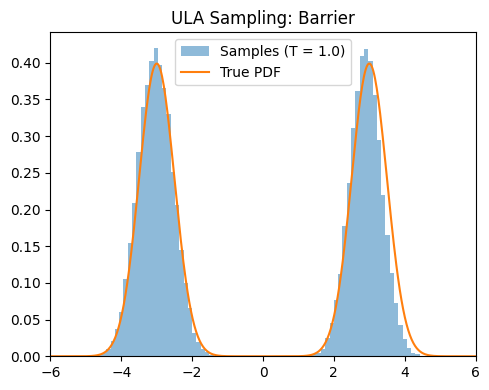

-0.22914302349090576
9.021909713745117


In [ ]:
for method in ["DDPM"]:
	for config in DATASETS.items():
		for n_steps in [10]:
			for scale in [0.2]:
				samples = plot_samples(config=config, temperature=1.0, method=method, step_scale=scale, n_langevin_steps = n_steps)
				print(samples.mean().item())
				print(samples.var().item())